In [116]:
import pandas as pd
import matplotlib
import seaborn

In [117]:

titanic = pd.read_csv("../data/titanic.csv")
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  1309 non-null   int64  
 1   pclass    1309 non-null   int64  
 2   name      1309 non-null   str    
 3   sex       1309 non-null   str    
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   ticket    1309 non-null   str    
 8   fare      1308 non-null   float64
 9   cabin     295 non-null    str    
 10  embarked  1307 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 112.6 KB


## Sobreviventes

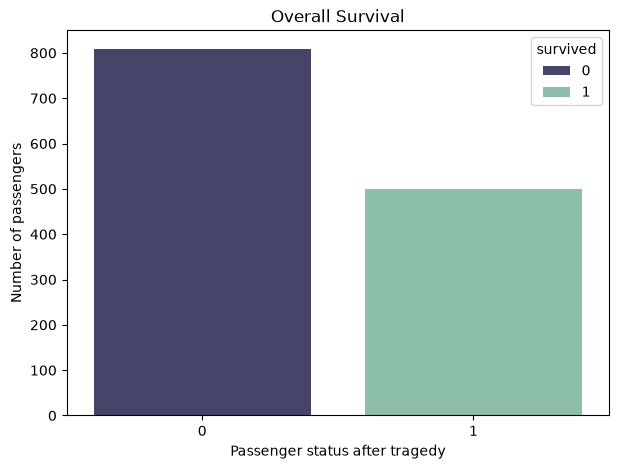

In [118]:
matplotlib.pyplot.figure(figsize=(7, 5))
seaborn.countplot(x='survived', hue='survived', data=titanic, palette=['#3F3E6FD1', '#85C6A9'])
matplotlib.pyplot.title('Overall Survival')
matplotlib.pyplot.xlabel('Passenger status after tragedy')
matplotlib.pyplot.ylabel('Number of passengers')
matplotlib.pyplot.show()

### Idade
Qual é a idade dos passageiros, como ela se relaciona com as chances de sobrevivência e como isso varia de acordo com a classe e gênero?

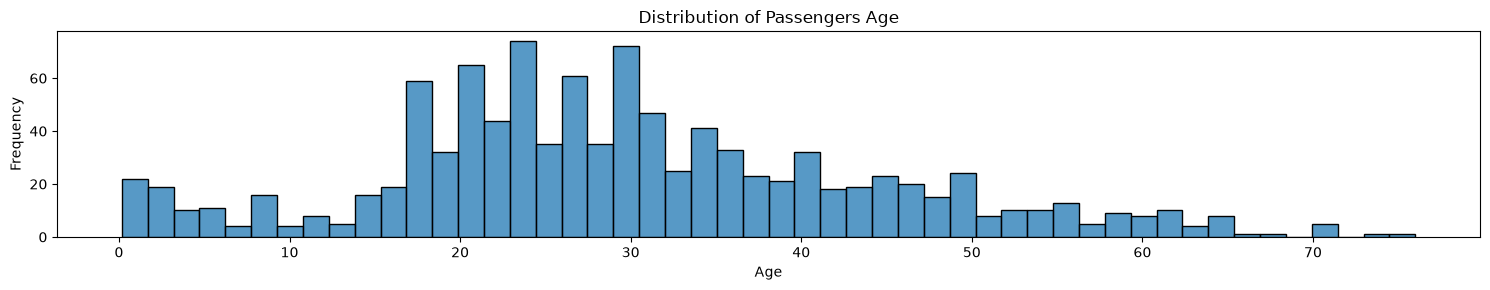

In [119]:
matplotlib.pyplot.figure(figsize=(15, 3))
seaborn.histplot(titanic[(titanic['age'] > 0)].age, bins=50)
matplotlib.pyplot.title('Distribution of Passengers Age')
matplotlib.pyplot.xlabel('Age')
matplotlib.pyplot.ylabel('Frequency')
matplotlib.pyplot.tight_layout()

In [120]:
titanic.groupby('survived')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,619.0,30.545363,13.922550,0.33,21.0,28.0,39.0,74.0
1,427.0,28.843302,14.885268,0.17,20.0,28.0,38.0,76.0


In [121]:
titanic.loc[titanic['age'] == 80]

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


In [122]:
titanic.loc[titanic['name'] == 'Barkworth, Mr. Algernon Henry Wilson', 'age'] = 48
titanic.loc[titanic['name'] == 'Barkworth, Mr. Algernon Henry Wilson']

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
12,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,48.0,0,0,27042,30.0,A23,S


In [123]:
titanic.to_csv('../data/titanic.csv', index=False)

## Engenharia de atributos
### Embarcado 
* S = Southampton
* C = Chebourg
* Q = Queenstown


In [124]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0]) # completar dados faltantes com a moda

In [125]:
titanic1 = titanic.copy()
titanic2 = titanic.copy()

# One-hot Encoding (recomended) - Neural Networks / Logistic Regression
titanic1 = pd.get_dummies(titanic1, columns=['embarked'], drop_first=True) # column to table

# Label/Ordinal Encoding - Tree-based models (Random Forest, Decision Tree, Gradient Boosting)
titanic2['embarked'] = titanic2['embarked'].map({'S' : 0, 'C' : 1, 'Q' : 2}) # column data to numbers

titanic = titanic1.copy()
titanic.head()

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked_Q,embarked_S
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,False,True
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,False,True
2,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,False,True
3,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,False,True
4,1,1,"Anderson, Mr. Harry",male,48.00,0,0,19952,26.5500,E12,False,True


### Nome


In [126]:
# 1 - Extrair o título entre a virgula e o ponto no nome
titanic['title'] = titanic['name'].str.extract(' ([A-Za-z]+)\\.', expand=True)

# 2 - Agrupar títulos raros ou equivalentes para evitar categorias com poucas observações
titanic['title'] = titanic['title'].replace(['Mlle', 'Ms'], 'Miss')
titanic['title'] = titanic['title'].replace('Mme', 'Mrs')

titulos_raros = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
titanic['title'] = titanic['title'].replace(titulos_raros, 'rare')

titanic = pd.get_dummies(titanic, columns=['title'], drop_first=True)
titanic.head()

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked_Q,embarked_S,title_Miss,title_Mr,title_Mrs,title_rare
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,False,True,True,False,False,False
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,False,True,False,False,False,False
2,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,False,True,True,False,False,False
3,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,False,True,False,False,True,False
4,1,1,"Anderson, Mr. Harry",male,48.00,0,0,19952,26.5500,E12,False,True,False,True,False,False


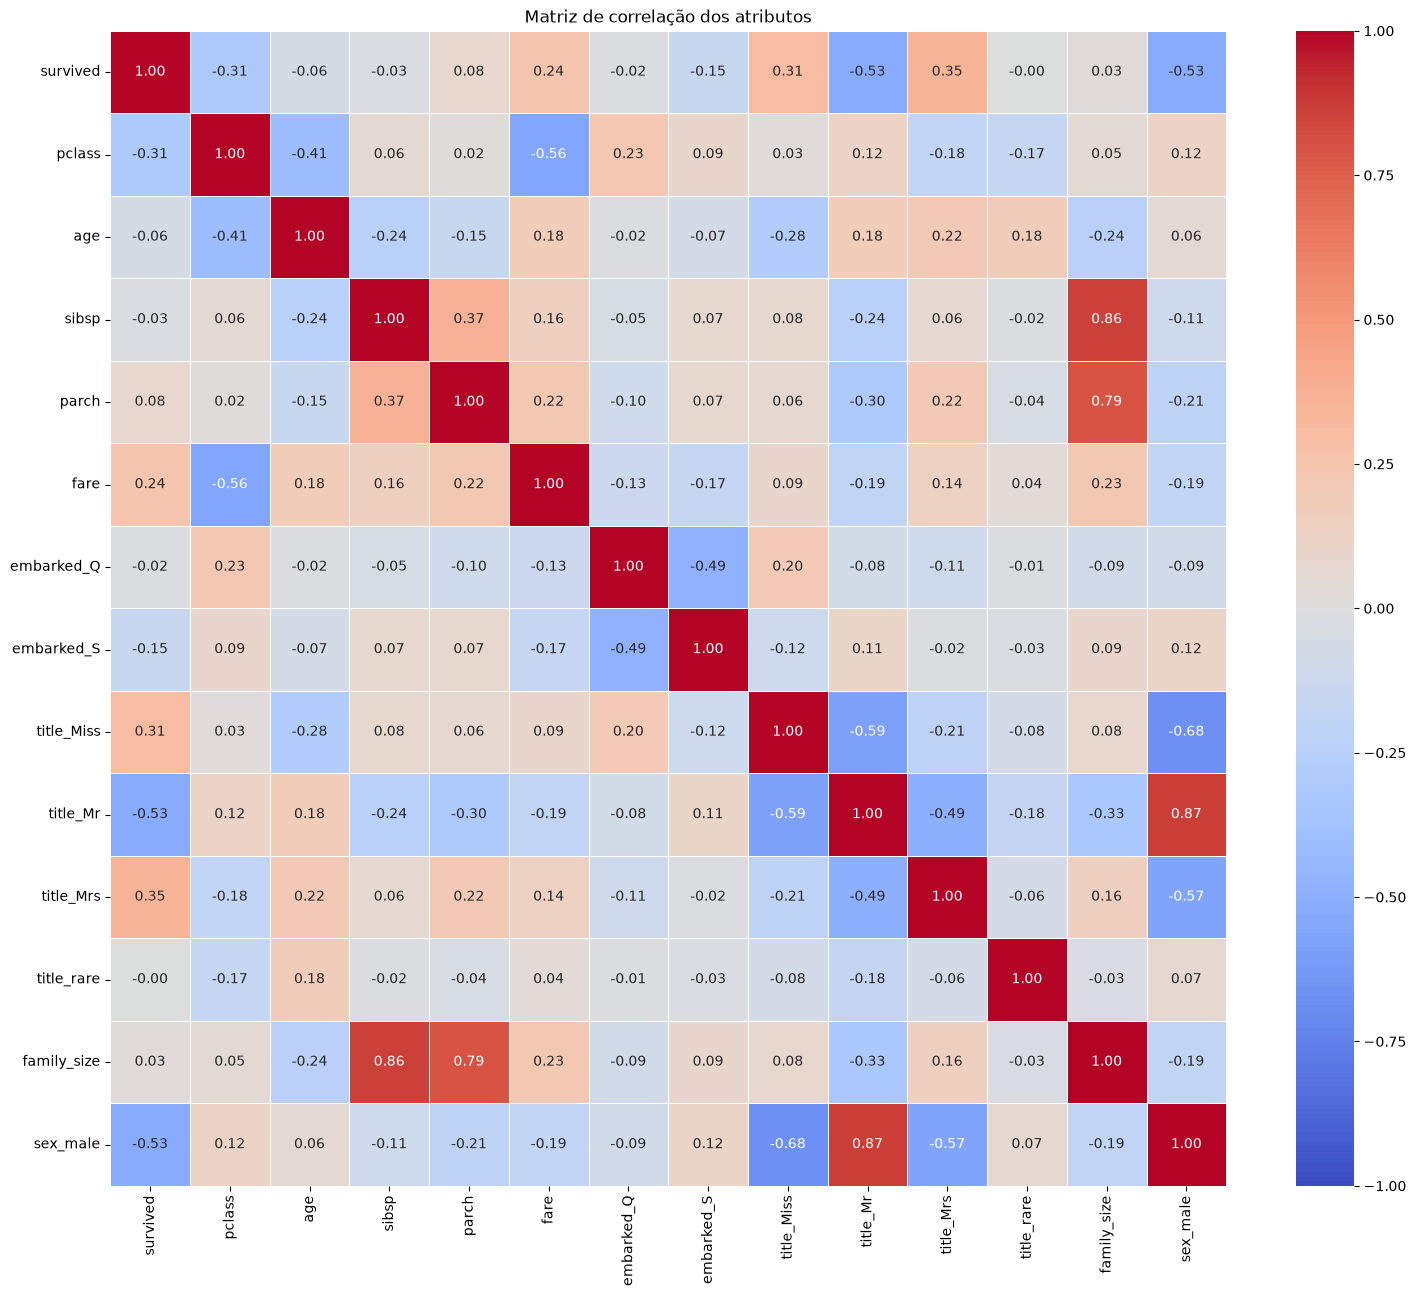

In [132]:
_titanic = titanic.select_dtypes(include=['number', 'bool'])

matplotlib.pyplot.figure(figsize=(18, 15))
seaborn.heatmap(
    data = _titanic.corr(),
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    vmin = -1,
    vmax = 1,
    linewidths = 0.5
)

matplotlib.pyplot.title('Matriz de correlação dos atributos')
matplotlib.pyplot.show()

In [128]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic = pd.get_dummies(titanic, columns=['sex'], drop_first=True) 
titanic.head()

,survived,pclass,name,age,sibsp,parch,ticket,fare,cabin,embarked_Q,embarked_S,title_Miss,title_Mr,title_Mrs,title_rare,family_size,sex_male
0,1,1,"Allen, Miss. Elisabeth Walton",29.00,0,0,24160,211.3375,B5,False,True,True,False,False,False,1,False
1,1,1,"Allison, Master. Hudson Trevor",0.92,1,2,113781,151.5500,C22 C26,False,True,False,False,False,False,4,True
2,0,1,"Allison, Miss. Helen Loraine",2.00,1,2,113781,151.5500,C22 C26,False,True,True,False,False,False,4,False
3,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.00,1,2,113781,151.5500,C22 C26,False,True,False,False,True,False,4,False
4,1,1,"Anderson, Mr. Harry",48.00,0,0,19952,26.5500,E12,False,True,False,True,False,False,1,True
